<a href="https://colab.research.google.com/github/roshan-mahato/PRT_661_WILDFIRE_PREDICTION/blob/feature%2Fcomponents/SpatialHoldouts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spatial holdout evaluation

This notebook performs **spatial validation**. It answers whether the model can generalise to geographic areas excluded from model development.

Complete contiguous 5-degree blocks are used instead of isolated neighbouring cells. Test blocks never appear in training or calibration, and a 100 km buffer removes development cells close to them.


## 2. Imports and fixed modelling rules


In [2]:
from datetime import datetime, timezone
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


RANDOM_STATE = 42
EARTH_RADIUS_KM = 6371.0088
CALIBRATION_BINS = np.linspace(0.0, 1.0, 11)

#excluding fields that could leak fire info
EXCLUDED_PREDICT_FEATURES = {"acq_time", "brightness", "bright_ti4", "bright_ti5", "confidence",
    "days_since_cell_start", "days_to_nearest_fire", "frp", "instrument","label", "satellite", "scan", "track", "type"}


## 3. Configuration

`RUN_MODEL = Train` to train and evaluate with LightGBM; use `False` to audit the spatial split only


In [3]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATASET_PATH = Path("/content/drive/MyDrive/DataScience_Spatial Holdouts/final_dataset.csv")
METADATA_PATH = Path("/content/drive/MyDrive/DataScience_Spatial Holdouts/best_fire_model_metadata.json")
OUTPUT_PATH = Path("/content/spatial_holdout_evaluation.json")

BLOCK_DEGREES = 5.0
TEST_FRACTION = 0.20
VALIDATION_FRACTION = 0.20
BUFFER_KM = 100.0
DROP_LOCATION_FEATURES = False
RUN_MODEL = True
#to check whether split settings are valid before executing
if not 0.0 < TEST_FRACTION < 1.0:
    raise ValueError("TEST_FRACTION must be between 0 and 1.")
if not 0.0 < VALIDATION_FRACTION < 1.0:
    raise ValueError("VALIDATION_FRACTION must be between 0 and 1.")
if TEST_FRACTION + VALIDATION_FRACTION >= 1.0:
    raise ValueError("Test and validation fractions must sum to less than 1.")
if not 0.0 < BLOCK_DEGREES <= 30.0:
    raise ValueError("BLOCK_DEGREES must be greater than 0 and no more than 30.")
if BUFFER_KM < 0.0:
    raise ValueError("BUFFER_KM cannot be negative.")

## 4. Load and validate the model contract and dataset


In [5]:
def load_model_contract(path: Path, drop_location: bool) -> tuple[list[str], float, int]:
    if not path.is_file():
        raise FileNotFoundError(f"Model metadata was not found: {path}")
    with path.open(encoding="utf-8") as stream:
        metadata = json.load(stream)

    features = metadata.get("features")
    if not isinstance(features, list) or not features or not all(isinstance(x, str) for x in features):
        raise ValueError("Model metadata must contain a non-empty string list named 'features'.")
    if len(features) != len(set(features)):
        raise ValueError("Model metadata contains duplicate feature names.")

    forbidden = sorted(set(features) & EXCLUDED_PREDICT_FEATURES)
    if forbidden:
        raise ValueError(f"The model contract contains leakage features: {forbidden}")
    if drop_location:
        features = [name for name in features if name not in {"lat_round", "lon_round"}]
    if not features:
        raise ValueError("No predictors remain after applying the requested exclusions.")

    rain_cap = float(metadata.get("days_since_rain_cap", 180.0))
    near_fire_days = int(metadata.get("train_buffer_days", 1))
    if rain_cap <= 0.0 or near_fire_days < 0:
        raise ValueError("Invalid rain cap or training buffer in model metadata.")
    return features, rain_cap, near_fire_days


def load_dataset(path: Path, features: list[str], rain_cap: float) -> tuple[pd.DataFrame, int]:
    if not path.is_file():
        raise FileNotFoundError(f"Labelled dataset was not found: {path}")

    required = list(dict.fromkeys(
        features + ["lat_round", "lon_round", "acq_date", "label", "days_to_nearest_fire"]
    ))
    available = pd.read_csv(path, nrows=0).columns.tolist()
    missing = [name for name in required if name not in available]
    if missing:
        raise ValueError(f"Dataset is missing required columns: {missing}")

    numeric = [name for name in required if name != "acq_date"]
    data = pd.read_csv(path, usecols=required, dtype={name: "float32" for name in numeric})
    data["acq_date"] = pd.to_datetime(data["acq_date"], errors="coerce")

    missing_counts = data[required].isna().sum()
    missing_counts = missing_counts[missing_counts > 0]
    if not missing_counts.empty:
        raise ValueError(f"Dataset contains missing or invalid values: {missing_counts.to_dict()}")
    if not data["label"].isin([0.0, 1.0]).all():
        raise ValueError("The label column must contain only 0 and 1.")
    data["label"] = data["label"].astype("int8")

    if not data["lat_round"].between(-90.0, 90.0).all():
        raise ValueError("Latitude values fall outside [-90, 90].")
    if not data["lon_round"].between(-180.0, 180.0).all():
        raise ValueError("Longitude values fall outside [-180, 180].")
    if data.duplicated(["lat_round", "lon_round", "acq_date"]).any():
        raise ValueError("Dataset contains duplicate grid-cell/day rows.")

    if "month_sin" in features:
        data["month_sin"] = np.sin(2.0 * np.pi * data["acq_date"].dt.month / 12.0).astype("float32")
    if "month_cos" in features:
        data["month_cos"] = np.cos(2.0 * np.pi * data["acq_date"].dt.month / 12.0).astype("float32")

    capped_rows = 0
    if "days_since_rain" in features:
        capped_rows = int((data["days_since_rain"] > rain_cap).sum())
        data["days_since_rain"] = data["days_since_rain"].clip(upper=rain_cap)
    if not np.isfinite(data[features].to_numpy(copy=False)).all():
        raise ValueError("One or more predictors contain infinite values.")
    return data, capped_rows


## 5. Create buffered spatial partitions

Occupied blocks are assigned with a fixed seed before inspecting class labels. Every row from a test cell stays in the test set. Development cells within the configured distance of any test cell are excluded.


In [6]:
def spatial_block_ids(
    latitude: np.ndarray,
    longitude: np.ndarray,
    block_degrees: float,
) -> tuple[np.ndarray, int]:
    latitude_bin = np.floor((latitude + 90.0) / block_degrees).astype("int32")
    longitude_bin = np.floor((longitude + 180.0) / block_degrees).astype("int32")
    longitude_bin_count = math.ceil(360.0 / block_degrees) + 1
    return latitude_bin * longitude_bin_count + longitude_bin, longitude_bin_count


def cell_codes(latitude: np.ndarray, longitude: np.ndarray) -> np.ndarray:
    latitude_key = np.rint((latitude + 90.0) * 1000.0).astype("int64")
    longitude_key = np.rint((longitude + 180.0) * 1000.0).astype("int64")
    return latitude_key * 1_000_000 + longitude_key


def block_bounds(block_ids: np.ndarray, block_degrees: float, longitude_bin_count: int) -> list[dict]:
    bounds = []
    for block_id in np.sort(block_ids):
        latitude_bin = int(block_id) // longitude_bin_count
        longitude_bin = int(block_id) % longitude_bin_count
        latitude_min = latitude_bin * block_degrees - 90.0
        longitude_min = longitude_bin * block_degrees - 180.0
        bounds.append({
            "block_id": int(block_id),
            "latitude_min": latitude_min,
            "latitude_max": min(latitude_min + block_degrees, 90.0),
            "longitude_min": longitude_min,
            "longitude_max": min(longitude_min + block_degrees, 180.0),
        })
    return bounds


def assign_blocks(
    occupied_blocks: np.ndarray,
    test_fraction: float,
    validation_fraction: float,
    random_state: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    block_count = len(occupied_blocks)
    if block_count < 3:
        raise ValueError("At least three occupied spatial blocks are required.")

    test_count = max(1, int(round(block_count * test_fraction)))
    validation_count = max(1, int(round(block_count * validation_fraction)))
    if test_count + validation_count >= block_count:
        raise ValueError("The requested fractions leave no training blocks.")

    rng = np.random.default_rng(random_state)
    shuffled = rng.permutation(np.sort(occupied_blocks))
    test_blocks = np.sort(shuffled[:test_count])
    validation_blocks = np.sort(shuffled[test_count:test_count + validation_count])
    train_blocks = np.sort(shuffled[test_count + validation_count:])
    return train_blocks, validation_blocks, test_blocks


def distance_to_test_cells(cells: pd.DataFrame, test_blocks: np.ndarray) -> np.ndarray:
    from sklearn.neighbors import BallTree

    test_cells = cells[cells["block_id"].isin(test_blocks)]
    if test_cells.empty:
        raise ValueError("No cells were assigned to the spatial test blocks.")
    test_radians = np.deg2rad(test_cells[["lat_round", "lon_round"]].to_numpy())
    all_radians = np.deg2rad(cells[["lat_round", "lon_round"]].to_numpy())
    distance, _ = BallTree(test_radians, metric="haversine").query(all_radians, k=1)
    return distance[:, 0] * EARTH_RADIUS_KM


def make_spatial_masks(
    data: pd.DataFrame,
    block_degrees: float,
    test_fraction: float,
    validation_fraction: float,
    buffer_km: float,
    random_state: int,
) -> tuple[dict[str, np.ndarray], dict]:
    latitude = data["lat_round"].to_numpy()
    longitude = data["lon_round"].to_numpy()
    row_blocks, longitude_bin_count = spatial_block_ids(latitude, longitude, block_degrees)
    row_cells = cell_codes(latitude, longitude)

    cells = data[["lat_round", "lon_round"]].drop_duplicates().copy()
    cells["block_id"], _ = spatial_block_ids(
        cells["lat_round"].to_numpy(), cells["lon_round"].to_numpy(), block_degrees
    )
    cells["cell_code"] = cell_codes(
        cells["lat_round"].to_numpy(), cells["lon_round"].to_numpy()
    )
    train_blocks, validation_blocks, test_blocks = assign_blocks(
        cells["block_id"].unique(), test_fraction, validation_fraction, random_state
    )

    cells["distance_to_test_km"] = distance_to_test_cells(cells, test_blocks)
    test_cell_mask = cells["block_id"].isin(test_blocks)
    development_far_enough = cells["distance_to_test_km"] > buffer_km

    train_cells = cells.loc[
        cells["block_id"].isin(train_blocks) & development_far_enough, "cell_code"
    ].to_numpy(dtype="int64")
    validation_cells = cells.loc[
        cells["block_id"].isin(validation_blocks) & development_far_enough, "cell_code"
    ].to_numpy(dtype="int64")
    test_cells = cells.loc[test_cell_mask, "cell_code"].to_numpy(dtype="int64")

    masks = {
        "train": np.isin(row_cells, train_cells),
        "validation": np.isin(row_cells, validation_cells),
        "test": np.isin(row_cells, test_cells),
    }
    if np.any(masks["train"] & masks["validation"]):
        raise RuntimeError("A cell appears in both training and validation.")
    if np.any(masks["train"] & masks["test"]) or np.any(masks["validation"] & masks["test"]):
        raise RuntimeError("A test cell appears in a development partition.")

    for name, mask in masks.items():
        if not mask.any():
            raise ValueError(f"The {name} partition is empty.")
        if data.loc[mask, "label"].nunique() != 2:
            raise ValueError(
                f"The {name} partition contains one class. Change the seed or block size."
            )

    development_cells = cells[cells["block_id"].isin(np.r_[train_blocks, validation_blocks])]
    excluded_by_buffer = int((development_cells["distance_to_test_km"] <= buffer_km).sum())
    kept_development = development_cells[development_cells["distance_to_test_km"] > buffer_km]
    minimum_distance = float(kept_development["distance_to_test_km"].min())

    details = {
        "block_degrees": block_degrees,
        "requested_test_fraction": test_fraction,
        "requested_validation_fraction": validation_fraction,
        "occupied_blocks": int(cells["block_id"].nunique()),
        "train_blocks": block_bounds(train_blocks, block_degrees, longitude_bin_count),
        "validation_blocks": block_bounds(validation_blocks, block_degrees, longitude_bin_count),
        "test_blocks": block_bounds(test_blocks, block_degrees, longitude_bin_count),
        "all_cells": int(len(cells)),
        "train_cells_after_buffer": int(len(train_cells)),
        "validation_cells_after_buffer": int(len(validation_cells)),
        "test_cells": int(len(test_cells)),
        "development_cells_excluded_by_buffer": excluded_by_buffer,
        "buffer_km": buffer_km,
        "minimum_development_to_test_distance_km": minimum_distance,
    }
    return masks, details


def apply_training_buffer(
    data: pd.DataFrame,
    train_mask: np.ndarray,
    near_fire_days: int,
) -> tuple[np.ndarray, int]:
    if near_fire_days == 0:
        return train_mask.copy(), 0
    labels = data["label"].to_numpy()
    distance = data["days_to_nearest_fire"].to_numpy()
    near_fire_negative = (
        train_mask & (labels == 0) & (distance > 0) & (distance <= near_fire_days)
    )
    fit_mask = train_mask & ~near_fire_negative
    if data.loc[fit_mask, "label"].nunique() != 2:
        raise ValueError("The near-fire buffer removed one class from training.")
    return fit_mask, int(near_fire_negative.sum())


def split_summary(data: pd.DataFrame, mask: np.ndarray, block_degrees: float) -> dict:
    subset = data.loc[mask, ["lat_round", "lon_round", "acq_date", "label"]]
    blocks, _ = spatial_block_ids(
        subset["lat_round"].to_numpy(), subset["lon_round"].to_numpy(), block_degrees
    )
    return {
        "rows": int(len(subset)),
        "cells": int(subset[["lat_round", "lon_round"]].drop_duplicates().shape[0]),
        "spatial_blocks": int(np.unique(blocks).size),
        "start_date": subset["acq_date"].min().date().isoformat(),
        "end_date": subset["acq_date"].max().date().isoformat(),
        "positive_rows": int(subset["label"].sum()),
        "positive_rate": float(subset["label"].mean()),
    }


## 6. Training, calibration and evaluation functions


In [7]:
def train_model(features: list[str], data: pd.DataFrame, masks: dict[str, np.ndarray]):
    import lightgbm as lgb
    from sklearn.calibration import CalibratedClassifierCV
    from sklearn.frozen import FrozenEstimator

    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=30,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )
    model.fit(data.loc[masks["fit_train"], features], data.loc[masks["fit_train"], "label"])
    calibrated = CalibratedClassifierCV(FrozenEstimator(model), method="isotonic")
    calibrated.fit(
        data.loc[masks["validation"], features], data.loc[masks["validation"], "label"]
    )
    return model, calibrated


def predict_partition(
    model,
    features: list[str],
    data: pd.DataFrame,
    mask: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    labels = data.loc[mask, "label"].to_numpy()
    probabilities = model.predict_proba(data.loc[mask, features])[:, 1]
    return labels, probabilities


def choose_f1_threshold(labels: np.ndarray, probabilities: np.ndarray) -> float:
    from sklearn.metrics import precision_recall_curve

    precision, recall, thresholds = precision_recall_curve(labels, probabilities)
    if len(thresholds) == 0:
        raise ValueError("Validation predictions do not provide a usable threshold.")
    f1 = 2.0 * precision * recall / np.clip(precision + recall, 1e-12, None)
    return float(thresholds[int(np.nanargmax(f1[:-1]))])


def evaluate(labels: np.ndarray, probabilities: np.ndarray, threshold: float, name: str) -> dict:
    from sklearn.metrics import (
        accuracy_score, average_precision_score, balanced_accuracy_score,
        brier_score_loss, confusion_matrix, f1_score, precision_score,
        recall_score, roc_auc_score,
    )

    predictions = (probabilities >= threshold).astype("int8")
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        "split": name,
        "threshold": float(threshold),
        "base_rate": float(labels.mean()),
        "mean_predicted": float(probabilities.mean()),
        "brier": float(brier_score_loss(labels, probabilities)),
        "accuracy": float(accuracy_score(labels, predictions)),
        "balanced_accuracy": float(balanced_accuracy_score(labels, predictions)),
        "precision_fire": float(precision_score(labels, predictions, zero_division=0)),
        "recall_fire": float(recall_score(labels, predictions, zero_division=0)),
        "f1_fire": float(f1_score(labels, predictions, zero_division=0)),
        "roc_auc": float(roc_auc_score(labels, probabilities)),
        "pr_auc": float(average_precision_score(labels, probabilities)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def reliability_table(labels: np.ndarray, probabilities: np.ndarray) -> list[dict]:
    bins = pd.cut(probabilities, CALIBRATION_BINS, include_lowest=True)
    table = (
        pd.DataFrame({"bin": bins, "predicted": probabilities, "observed": labels})
        .groupby("bin", observed=True)
        .agg(rows=("observed", "size"), predicted=("predicted", "mean"),
             observed=("observed", "mean"))
        .reset_index()
    )
    table["bin"] = table["bin"].astype(str)
    return table.to_dict(orient="records")


def gain_importance(model, features: list[str]) -> list[dict]:
    gain = model.booster_.feature_importance(importance_type="gain")
    total = float(gain.sum())
    share = gain / total if total > 0.0 else np.zeros_like(gain, dtype=float)
    order = np.argsort(gain)[::-1]
    return [
        {"feature": features[index], "gain": float(gain[index]),
         "gain_share": float(share[index])}
        for index in order
    ]


def write_results(path: Path, results: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as stream:
        json.dump(results, stream, indent=2, allow_nan=False)
        stream.write("\n")


## 7. Build and audit the spatial holdout


In [8]:
features, rain_cap, near_fire_days = load_model_contract(
    METADATA_PATH,
    DROP_LOCATION_FEATURES,
)
data, capped_rows = load_dataset(DATASET_PATH, features, rain_cap)
masks, spatial_details = make_spatial_masks(
    data,
    BLOCK_DEGREES,
    TEST_FRACTION,
    VALIDATION_FRACTION,
    BUFFER_KM,
    RANDOM_STATE,
)
masks["fit_train"], removed_near_fire = apply_training_buffer(
    data,
    masks["train"],
    near_fire_days,
)

split_details = {
    name: split_summary(data, mask, BLOCK_DEGREES)
    for name, mask in masks.items()
}
date_ranges = {
    (details["start_date"], details["end_date"])
    for name, details in split_details.items()
    if name != "fit_train"
}
if len(date_ranges) != 1:
    raise ValueError(
        "The spatial partitions do not cover the same date range. "
        "Check whether every grid cell has a complete daily series."
    )

summary = pd.DataFrame(split_details).T
display(summary)
print(f"Rows loaded: {len(data):,}")
print(f"Predictors: {len(features)}")
print(f"Date range shared by all partitions: {next(iter(date_ranges))}")
print(
    "Minimum retained development-to-test distance: "
    f"{spatial_details['minimum_development_to_test_distance_km']:.2f} km"
)

results = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "method": "buffered spatial block holdout",
    "purpose": "Evaluate locations excluded from training and calibration.",
    "input": str(DATASET_PATH),
    "model_metadata": str(METADATA_PATH),
    "features": features,
    "location_features_removed": DROP_LOCATION_FEATURES,
    "configuration": {
        "random_state": RANDOM_STATE,
        "days_since_rain_cap": rain_cap,
        "days_since_rain_rows_capped": capped_rows,
        "train_near_fire_buffer_days": near_fire_days,
        "train_near_fire_negatives_removed": removed_near_fire,
    },
    "spatial_holdout": spatial_details,
    "splits": split_details,
    "all_splits_use_the_same_date_range": True,
    "split_only": not RUN_MODEL,
}


,rows,cells,spatial_blocks,start_date,end_date,positive_rows,positive_rate
train,1582734,1578,28,2024-01-01,2026-09-29,112547,0.071109
validation,491470,490,9,2024-01-01,2026-09-29,27800,0.056565
test,548641,547,10,2024-01-01,2026-09-29,44922,0.081879
fit_train,1503857,1578,28,2024-01-01,2026-09-29,112547,0.074839


Rows loaded: 2,869,583
Predictors: 27
Date range shared by all partitions: ('2024-01-01', '2026-09-29')
Minimum retained development-to-test distance: 100.78 km


## 8. Visual check of held-out locations


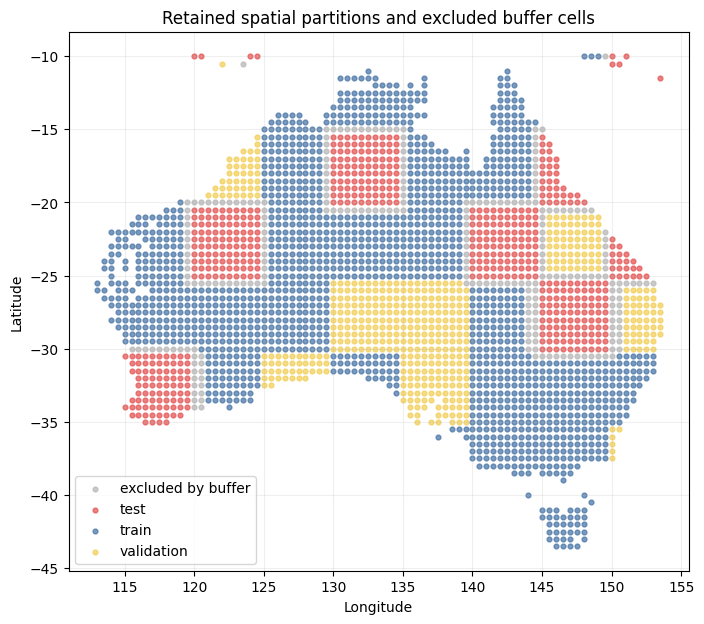

In [9]:
cell_view = data[["lat_round", "lon_round"]].drop_duplicates().copy()
cell_view["cell_code"] = cell_codes(
    cell_view["lat_round"].to_numpy(),
    cell_view["lon_round"].to_numpy(),
)
retained_cells = {}
for name in ("train", "validation", "test"):
    subset = data.loc[masks[name], ["lat_round", "lon_round"]].drop_duplicates()
    retained_cells[name] = set(
        cell_codes(
            subset["lat_round"].to_numpy(),
            subset["lon_round"].to_numpy(),
        )
    )
cell_view["partition"] = "excluded by buffer"
for name in ("train", "validation", "test"):
    cell_view.loc[
        cell_view["cell_code"].isin(retained_cells[name]), "partition"
    ] = name

colours = {
    "train": "#4C78A8",
    "validation": "#F2CF5B",
    "test": "#E45756",
    "excluded by buffer": "#B8B8B8",
}
fig, axis = plt.subplots(figsize=(8, 7))
for partition, subset in cell_view.groupby("partition"):
    axis.scatter(
        subset["lon_round"], subset["lat_round"],
        s=12, alpha=0.75, label=partition, color=colours[partition],
    )
axis.set(
    title="Retained spatial partitions and excluded buffer cells",
    xlabel="Longitude",
    ylabel="Latitude",
)
axis.legend()
axis.grid(alpha=0.2)
plt.show()


## 9. Train and evaluate

The base model is fitted only on training blocks. Isotonic calibration and the F1 threshold use validation blocks only. The spatial test blocks are evaluated once at the fixed 0.50 threshold and the validation-selected threshold.


In [10]:
if not RUN_MODEL:
    write_results(OUTPUT_PATH, results)
    print(f"Spatial split audit saved to: {OUTPUT_PATH}")
else:
    base_model, calibrated_model = train_model(features, data, masks)
    validation_labels, validation_probabilities = predict_partition(
        calibrated_model, features, data, masks["validation"]
    )
    test_labels, test_probabilities = predict_partition(
        calibrated_model, features, data, masks["test"]
    )
    threshold = choose_f1_threshold(validation_labels, validation_probabilities)
    metrics = [
        evaluate(
            validation_labels, validation_probabilities, 0.50,
            "validation (threshold = 0.50)",
        ),
        evaluate(
            validation_labels, validation_probabilities, threshold,
            "validation (tuned)",
        ),
        evaluate(
            test_labels, test_probabilities, 0.50,
            "spatial test (threshold = 0.50)",
        ),
        evaluate(
            test_labels, test_probabilities, threshold,
            "spatial test (tuned)",
        ),
    ]
    results.update({
        "threshold_f1_optimal_on_validation": threshold,
        "metrics": metrics,
        "test_reliability": reliability_table(test_labels, test_probabilities),
        "feature_gain_importance": gain_importance(base_model, features),
    })
    write_results(OUTPUT_PATH, results)

    metric_table = pd.DataFrame(metrics)
    display(metric_table)
    display(pd.DataFrame(results["test_reliability"]))
    display(pd.DataFrame(results["feature_gain_importance"]).head(15))
    print(f"Evaluation saved to: {OUTPUT_PATH}")


,split,threshold,base_rate,mean_predicted,brier,accuracy,balanced_accuracy,precision_fire,recall_fire,f1_fire,roc_auc,pr_auc,tn,fp,fn,tp
0,validation (threshold = 0.50),0.50000,0.056565,0.056565,0.045116,0.944381,0.527215,0.586271,0.056835,0.103624,0.882764,0.262365,462555,1115,26220,1580
1,validation (tuned),0.17055,0.056565,0.056565,0.045116,0.875848,0.718888,0.237817,0.541906,0.330565,0.882764,0.262365,415388,48282,12735,15065
2,spatial test (threshold = 0.50),0.50000,0.081879,0.081418,0.071198,0.916942,0.507721,0.359164,0.018365,0.034944,0.742093,0.182284,502247,1472,44097,825
3,spatial test (tuned),0.17055,0.081879,0.081418,0.071198,0.822108,0.633923,0.205429,0.408887,0.273466,0.742093,0.182284,432674,71045,26554,18368


,bin,rows,predicted,observed
0,"(-0.001, 0.1]",340383,0.020359,0.035912
1,"(0.1, 0.2]",130256,0.150150,0.125069
2,"(0.2, 0.3]",73070,0.214574,0.202162
3,"(0.3, 0.4]",822,0.366258,0.304136
4,"(0.4, 0.5]",1820,0.470117,0.307692
5,"(0.5, 0.6]",2128,0.582669,0.360432
6,"(0.6, 0.7]",159,0.648886,0.352201
7,"(0.8, 0.9]",1,0.819092,1.000000
8,"(0.9, 1.0]",2,1.000000,0.500000


,feature,gain,gain_share
0,lat_round,1.399148e+06,0.353150
1,lon_round,9.114639e+05,0.230057
2,ffdi_max,4.244785e+05,0.107140
3,month_cos,2.711817e+05,0.068447
4,month_sin,2.158420e+05,0.054479
5,days_since_rain,1.103266e+05,0.027847
6,precipitation,8.879310e+04,0.022412
7,soil_moisture_0_to_7cm,8.667742e+04,0.021878
8,relative_humidity_2m_min,8.348170e+04,0.021071
9,kbdi,6.626189e+04,0.016725


Evaluation saved to: /content/spatial_holdout_evaluation.json
